# Optimization Methods

This notebook compares four optimization methods using the same cost functional:

- Gradient Descent
- Gradient Descent with Armijo condition
- Stochastic Gradient Descent
- Adam

We use the notation

- $\boldsymbol{\theta}$ = vector of parameters
- $J(\boldsymbol{\theta})$ = cost functional

and the common least-squares functional

\begin{equation}
J(\boldsymbol{\theta}) = \frac{1}{2m}\|X\boldsymbol{\theta} - \boldsymbol{y}\|_2^2.
\end{equation}

The main idea is:
- define the cost functional.
- define its gradient.
- implement each optimizer.
- test the same optimizers under different scenarios.


## Imports


In [1]:
# Import NumPy for vector and matrix computations.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


## Common cost functional and gradient

We define only one cost functional and only one gradient.

For mini-batch methods, we simply evaluate the same gradient on a subset of rows of $X$ and $\boldsymbol{y}$.


In [2]:
# Define the least-squares cost functional.
def cost(theta, X, y):
    # Compute the residual vector.
    residual = X @ theta - y

    # Return the average squared residual with factor 1/2.
    return 0.5 * np.mean(residual ** 2)


# Define the gradient of the least-squares cost functional.
def grad(theta, X, y):
    # Compute the residual vector.
    residual = X @ theta - y

    # Return the gradient of J(theta).
    return (X.T @ residual) / X.shape[0]


## Optimization routines

All methods return the same outputs:

- `method`
- `theta`
- `theta_history`
- `cost_history`
- `grad_norm_history`
- `step_history`

This makes the comparison easier.


### Gradient Descent

This method uses the full gradient and a fixed step size:

\begin{equation}
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \alpha_k \nabla J(\boldsymbol{\theta}_k).
\end{equation}


In [3]:
# Define Gradient Descent with fixed step size.
def gradient_descent(theta0, X, y, alpha, n_iters):
    # Copy the initial parameter vector.
    theta = theta0.copy()

    # Store the parameter history.
    theta_history = [theta.copy()]

    # Store the cost history.
    cost_history = [cost(theta, X, y)]

    # Store the gradient norm history.
    grad_norm_history = [np.linalg.norm(grad(theta, X, y))]

    # Store the step-size history.
    step_history = [0.0]

    # Run the iterations.
    for iter in range(n_iters):
        # Compute the full gradient.
        g = grad(theta, X, y)

        # Update the parameter vector.
        theta = theta - alpha * g

        # Store the new parameter vector.
        theta_history.append(theta.copy())

        # Store the new cost value.
        cost_history.append(cost(theta, X, y))

        # Store the new gradient norm.
        grad_norm_history.append(np.linalg.norm(grad(theta, X, y)))

        # Store the step size.
        step_history.append(alpha)

    # Return the standard output dictionary.
    return {
        "method": "Gradient Descent",
        "theta": theta,
        "theta_history": np.array(theta_history),
        "cost_history": np.array(cost_history),
        "grad_norm_history": np.array(grad_norm_history),
        "step_history": np.array(step_history),
    }


### Gradient Descent with Armijo condition

This method uses the full gradient, but the step size is chosen by backtracking so that the cost decreases sufficiently.


In [4]:
# Define Gradient Descent with Armijo backtracking.
def gradient_descent_armijo(theta0, X, y, alpha0, c, tau, n_iters):
    # Copy the initial parameter vector.
    theta = theta0.copy()

    # Store the parameter history.
    theta_history = [theta.copy()]

    # Store the cost history.
    cost_history = [cost(theta, X, y)]

    # Store the gradient norm history.
    grad_norm_history = [np.linalg.norm(grad(theta, X, y))]

    # Store the step-size history.
    step_history = [0.0]

    # Run the iterations.
    for iter in range(n_iters):
        # Compute the full gradient.
        g = grad(theta, X, y)

        # Define the descent direction.
        p = -g

        # Initialize the trial step size.
        alpha = alpha0

        # Compute the current cost.
        current_cost = cost(theta, X, y)

        # Apply Armijo backtracking.
        while cost(theta + alpha * p, X, y) > current_cost + c * alpha * (g @ p):
            # Reduce the step size.
            alpha = tau * alpha

        # Update the parameter vector.
        theta = theta + alpha * p

        # Store the new parameter vector.
        theta_history.append(theta.copy())

        # Store the new cost value.
        cost_history.append(cost(theta, X, y))

        # Store the new gradient norm.
        grad_norm_history.append(np.linalg.norm(grad(theta, X, y)))

        # Store the accepted step size.
        step_history.append(alpha)

    # Return the standard output dictionary.
    return {
        "method": "Gradient Descent + Armijo",
        "theta": theta,
        "theta_history": np.array(theta_history),
        "cost_history": np.array(cost_history),
        "grad_norm_history": np.array(grad_norm_history),
        "step_history": np.array(step_history),
    }


### Stochastic Gradient Descent

This method uses the same gradient formula, but evaluated on a random mini-batch instead of the full dataset.


In [5]:
# Define Stochastic Gradient Descent.
def stochastic_gradient_descent(theta0, X, y, alpha, n_iters, batch_size, seed):
    # Create a random generator for reproducibility.
    rng = np.random.default_rng(seed)

    # Copy the initial parameter vector.
    theta = theta0.copy()

    # Store the parameter history.
    theta_history = [theta.copy()]

    # Store the full cost history.
    cost_history = [cost(theta, X, y)]

    # Store the full gradient norm history.
    grad_norm_history = [np.linalg.norm(grad(theta, X, y))]

    # Store the step-size history.
    step_history = [0.0]

    # Get the number of samples.
    m = X.shape[0]

    # Run the iterations.
    for iter in range(n_iters):
        # Select a random mini-batch.
        batch_idx = rng.choice(m, size=batch_size, replace=False)

        # Extract the mini-batch matrix.
        X_batch = X[batch_idx]

        # Extract the mini-batch target vector.
        y_batch = y[batch_idx]

        # Compute the mini-batch gradient using the same common function.
        g = grad(theta, X_batch, y_batch)

        # Update the parameter vector.
        theta = theta - alpha * g

        # Store the new parameter vector.
        theta_history.append(theta.copy())

        # Store the full cost value for comparison.
        cost_history.append(cost(theta, X, y))

        # Store the full gradient norm for comparison.
        grad_norm_history.append(np.linalg.norm(grad(theta, X, y)))

        # Store the step size.
        step_history.append(alpha)

    # Return the standard output dictionary.
    return {
        "method": "Stochastic Gradient Descent",
        "theta": theta,
        "theta_history": np.array(theta_history),
        "cost_history": np.array(cost_history),
        "grad_norm_history": np.array(grad_norm_history),
        "step_history": np.array(step_history),
    }


### Adam

Adam combines:
- stochastic gradients
- momentum
- adaptive scaling

It uses the same mini-batch gradient formula as SGD, but transforms it using running first and second moments.


In [6]:
# Define Adam.
def adam(theta0, X, y, alpha, n_iters, batch_size, beta1, beta2, epsilon, seed):
    # Create a random generator for reproducibility.
    rng = np.random.default_rng(seed)

    # Copy the initial parameter vector.
    theta = theta0.copy()

    # Initialize the first-moment vector.
    m_vec = np.zeros_like(theta)

    # Initialize the second-moment vector.
    v_vec = np.zeros_like(theta)

    # Store the parameter history.
    theta_history = [theta.copy()]

    # Store the full cost history.
    cost_history = [cost(theta, X, y)]

    # Store the full gradient norm history.
    grad_norm_history = [np.linalg.norm(grad(theta, X, y))]

    # Store the step-size history.
    step_history = [0.0]

    # Get the number of samples.
    m = X.shape[0]

    # Run the iterations.
    for iter in range(1, n_iters + 1):
        # Select a random mini-batch.
        batch_idx = rng.choice(m, size=batch_size, replace=False)

        # Extract the mini-batch matrix.
        X_batch = X[batch_idx]

        # Extract the mini-batch target vector.
        y_batch = y[batch_idx]

        # Compute the mini-batch gradient using the same common function.
        g = grad(theta, X_batch, y_batch)

        # Update the first moment.
        m_vec = beta1 * m_vec + (1.0 - beta1) * g

        # Update the second moment.
        v_vec = beta2 * v_vec + (1.0 - beta2) * (g ** 2)

        # Compute the bias-corrected first moment.
        m_hat = m_vec / (1.0 - beta1 ** iter)

        # Compute the bias-corrected second moment.
        v_hat = v_vec / (1.0 - beta2 ** iter)

        # Update the parameter vector.
        theta = theta - alpha * m_hat / (np.sqrt(v_hat) + epsilon)

        # Store the new parameter vector.
        theta_history.append(theta.copy())

        # Store the full cost value for comparison.
        cost_history.append(cost(theta, X, y))

        # Store the full gradient norm for comparison.
        grad_norm_history.append(np.linalg.norm(grad(theta, X, y)))

        # Store the nominal step size.
        step_history.append(alpha)

    # Return the standard output dictionary.
    return {
        "method": "Adam",
        "theta": theta,
        "theta_history": np.array(theta_history),
        "cost_history": np.array(cost_history),
        "grad_norm_history": np.array(grad_norm_history),
        "step_history": np.array(step_history),
    }


## Utilities for experiments

The next cells build synthetic least-squares datasets and provide plotting utilities.


In [7]:
# Define a utility to build synthetic least-squares datasets with controlled singular values.
def build_dataset(n_samples, n_features, singular_values, noise_std, seed):
    # Create a random generator for reproducibility.
    rng = np.random.default_rng(seed)

    # Generate a random matrix.
    M = rng.normal(size=(n_samples, n_features))

    # Compute an orthonormal basis.
    U, _ = np.linalg.qr(M)

    # Generate another random square matrix.
    N = rng.normal(size=(n_features, n_features))

    # Compute an orthogonal matrix.
    V, _ = np.linalg.qr(N)

    # Build the design matrix with prescribed singular values.
    X = U @ np.diag(singular_values) @ V.T

    # Generate the true parameter vector.
    theta_true = rng.normal(size=n_features)

    # Generate the noiseless targets.
    y_clean = X @ theta_true

    # Add Gaussian noise to the targets.
    y = y_clean + noise_std * rng.normal(size=n_samples)

    # Return the dataset.
    return X, y, theta_true


# Define a utility to run all methods.
def run_all_methods(theta0, X, y, config):
    # Run Gradient Descent.
    gd_result = gradient_descent(
        theta0=theta0,
        X=X,
        y=y,
        alpha=config["gd_alpha"],
        n_iters=config["n_iters"],
    )

    # Run Gradient Descent with Armijo.
    armijo_result = gradient_descent_armijo(
        theta0=theta0,
        X=X,
        y=y,
        alpha0=config["armijo_alpha0"],
        c=config["armijo_c"],
        tau=config["armijo_tau"],
        n_iters=config["n_iters"],
    )

    # Run Stochastic Gradient Descent.
    sgd_result = stochastic_gradient_descent(
        theta0=theta0,
        X=X,
        y=y,
        alpha=config["sgd_alpha"],
        n_iters=config["n_iters"],
        batch_size=config["batch_size"],
        seed=config["seed"],
    )

    # Run Adam.
    adam_result = adam(
        theta0=theta0,
        X=X,
        y=y,
        alpha=config["adam_alpha"],
        n_iters=config["n_iters"],
        batch_size=config["batch_size"],
        beta1=config["beta1"],
        beta2=config["beta2"],
        epsilon=config["epsilon"],
        seed=config["seed"],
    )

    # Return the list of results.
    return [gd_result, armijo_result, sgd_result, adam_result]


# Define a utility to plot cost histories.
def plot_cost_histories(results, title):
    # Create a new figure.
    plt.figure(figsize=(8, 5))

    # Plot each cost history.
    for result in results:
        plt.plot(result["cost_history"], label=result["method"])

    # Use logarithmic vertical scale.
    plt.yscale("log")

    # Add labels and title.
    plt.xlabel("Iteration")
    plt.ylabel("J(theta)")
    plt.title(title)

    # Add legend and grid.
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Display the plot.
    plt.show()


# Define a utility to plot gradient norm histories.
def plot_grad_norm_histories(results, title):
    # Create a new figure.
    plt.figure(figsize=(8, 5))

    # Plot each gradient norm history.
    for result in results:
        plt.plot(result["grad_norm_history"], label=result["method"])

    # Use logarithmic vertical scale.
    plt.yscale("log")

    # Add labels and title.
    plt.xlabel("Iteration")
    plt.ylabel("||grad J(theta)||")
    plt.title(title)

    # Add legend and grid.
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Display the plot.
    plt.show()


# Define a utility to summarize the final values.
def build_summary_table(results):
    # Initialize the summary rows.
    rows = []

    # Process each method.
    for result in results:
        # Append one summary row.
        rows.append(
            {
                "Method": result["method"],
                "Final cost": result["cost_history"][-1],
                "Final grad norm": result["grad_norm_history"][-1],
                "Iterations": len(result["cost_history"]) - 1,
            }
        )

    # Return the summary table.
    return pd.DataFrame(rows)


## Scenario A: easy least-squares problem

This first scenario is simple:
- moderate conditioning
- low noise
- small dimension

Here, Gradient Descent can already perform very well.


In [8]:
# Fix the random seed.
np.random.seed(1)

# Define the easy dataset dimensions.
n_samples_easy = 300
n_features_easy = 8

# Define moderate singular values.
singular_values_easy = np.linspace(5.0, 1.0, n_features_easy)

# Build the easy dataset.
X_easy, y_easy, theta_true_easy = build_dataset(
    n_samples=n_samples_easy,
    n_features=n_features_easy,
    singular_values=singular_values_easy,
    noise_std=0.05,
    seed=10,
)

# Define the initial parameter vector.
theta0_easy = np.zeros(n_features_easy)

# Define the configuration for the easy scenario.
config_easy = {
    "n_iters": ,
    "gd_alpha": ,
    "armijo_alpha0": ,
    "armijo_c": ,
    "armijo_tau": ,
    "sgd_alpha": ,
    "adam_alpha": ,
    "batch_size": ,
    "beta1": ,
    "beta2": ,
    "epsilon": ,
    "seed": 123,
}

# Run all methods.
results_easy = run_all_methods(theta0_easy, X_easy, y_easy, config_easy)

# Build the summary table.
summary_easy = build_summary_table(results_easy)

# Display the summary table.
summary_easy


,Method,Final cost,Final grad norm,Iterations
0,Gradient Descent,0.039157,0.051416,150
1,Gradient Descent + Armijo,0.003128,0.005094,150
2,Stochastic Gradient Descent,0.385265,0.234777,150
3,Adam,0.001376,0.001438,150


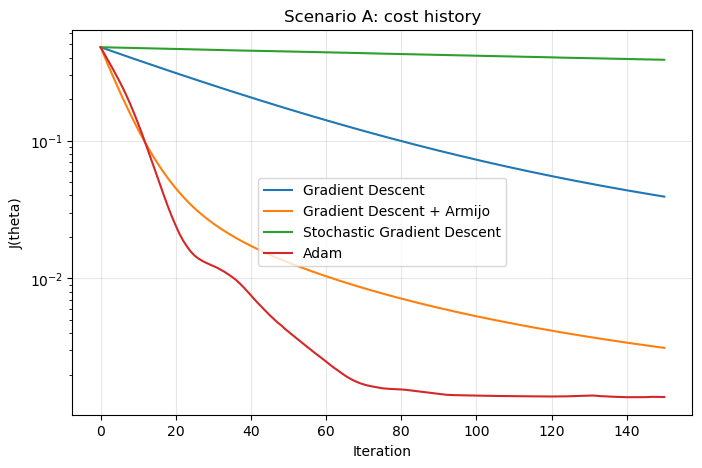

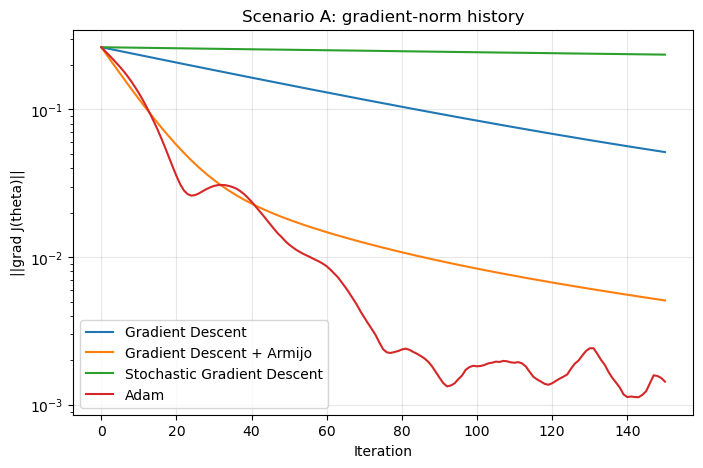

In [9]:
# Plot the cost histories for the easy scenario.
plot_cost_histories(results_easy, "Scenario A: cost history")

# Plot the gradient norm histories for the easy scenario.
plot_grad_norm_histories(results_easy, "Scenario A: gradient-norm history")


### Observation

This problem is easy enough that full Gradient Descent is already competitive.

We now move to a scenario designed so that:
- full gradients are expensive
- mini-batch updates are attractive
- ill-conditioning hurts plain Gradient Descent
- Adam benefits from adaptive scaling


## Scenario B: large-scale ill-conditioned least-squares problem

This second scenario uses the same cost functional, but now:
- many samples
- ill-conditioned geometry
- larger dimension
- mini-batch methods are much cheaper per iteration

In this setting, SGD and Adam should become more attractive than in Scenario A.


In [10]:
# Fix the random seed.
np.random.seed(2)

# Define the hard dataset dimensions.
n_samples_hard = 30000
n_features_hard = 60

# Define strongly ill-conditioned singular values.
singular_values_hard = np.geomspace(80.0, 0.05, n_features_hard)

# Build the harder dataset.
X_hard, y_hard, theta_true_hard = build_dataset(
    n_samples=n_samples_hard,
    n_features=n_features_hard,
    singular_values=singular_values_hard,
    noise_std=0.15,
    seed=20,
)

# Define the initial parameter vector.
theta0_hard = np.zeros(n_features_hard)

# Define the configuration for the hard scenario.
config_hard = {
    "n_iters": ,
    "gd_alpha": ,
    "armijo_alpha0": ,
    "armijo_c": ,
    "armijo_tau": ,
    "sgd_alpha": ,
    "adam_alpha": ,
    "batch_size": ,
    "beta1": ,
    "beta2": ,
    "epsilon": ,
    "seed": 456,
}

# Run all methods.
results_hard = run_all_methods(theta0_hard, X_hard, y_hard, config_hard)

# Build the summary table.
summary_hard = build_summary_table(results_hard)

# Display the summary table.
summary_hard


,Method,Final cost,Final grad norm,Iterations
0,Gradient Descent,0.304869,0.271725,220
1,Gradient Descent + Armijo,0.014522,0.004203,220
2,Stochastic Gradient Descent,0.130046,0.143805,220
3,Adam,0.012773,0.008933,220


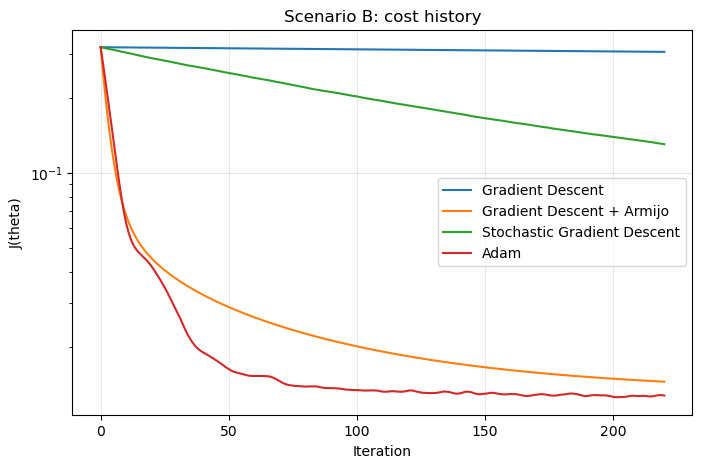

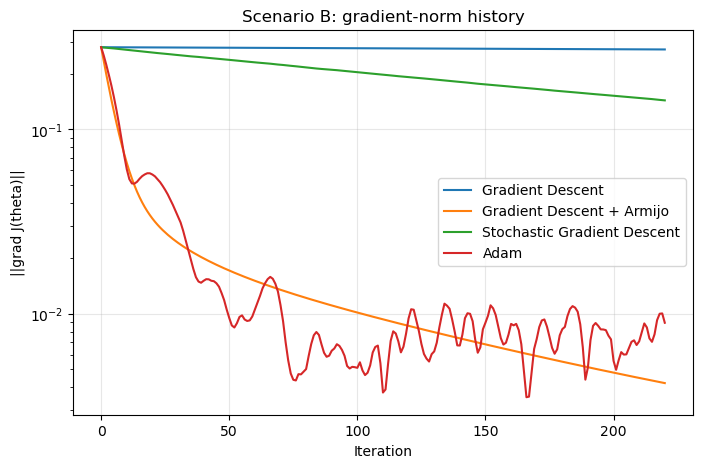

In [11]:
# Plot the cost histories for the hard scenario.
plot_cost_histories(results_hard, "Scenario B: cost history")

# Plot the gradient norm histories for the hard scenario.
plot_grad_norm_histories(results_hard, "Scenario B: gradient-norm history")


### Observation

This scenario is designed to highlight practical advantages:

- Gradient Descent and Armijo use the full dataset at every iteration
- SGD and Adam use only mini-batches
- Adam also adapts the scaling per coordinate

So even if full-gradient methods may still reduce the cost well, the mini-batch methods are now much more realistic for large datasets.


## Scenario B bis: noisy mini-batch regime

To make the difference even clearer, we now keep the same large-scale setting but use:
- smaller mini-batches
- more label noise
- a geometry where adaptive methods are especially useful

This makes SGD noisier and often favors Adam over plain SGD.


In [12]:
# Build a noisier large-scale dataset.
X_hard2, y_hard2, theta_true_hard2 = build_dataset(
    n_samples=30000,
    n_features=60,
    singular_values=np.geomspace(100.0, 0.03, 60),
    noise_std=0.35,
    seed=30,
)

# Define the initial parameter vector.
theta0_hard2 = np.zeros(60)

# Define a harder stochastic configuration.
config_hard2 = {
    "n_iters": ,
    "gd_alpha": ,
    "armijo_alpha0": ,
    "armijo_c": ,
    "armijo_tau": ,
    "sgd_alpha": ,
    "adam_alpha": ,
    "batch_size": ,
    "beta1": ,
    "beta2": ,
    "epsilon": ,
    "seed": 789,
}

# Run all methods.
results_hard2 = run_all_methods(theta0_hard2, X_hard2, y_hard2, config_hard2)

# Build the summary table.
summary_hard2 = build_summary_table(results_hard2)

# Display the summary table.
summary_hard2


,Method,Final cost,Final grad norm,Iterations
0,Gradient Descent,0.350849,0.288958,260
1,Gradient Descent + Armijo,0.067036,0.004070,260
2,Stochastic Gradient Descent,0.219993,0.182117,260
3,Adam,0.070661,0.044361,260


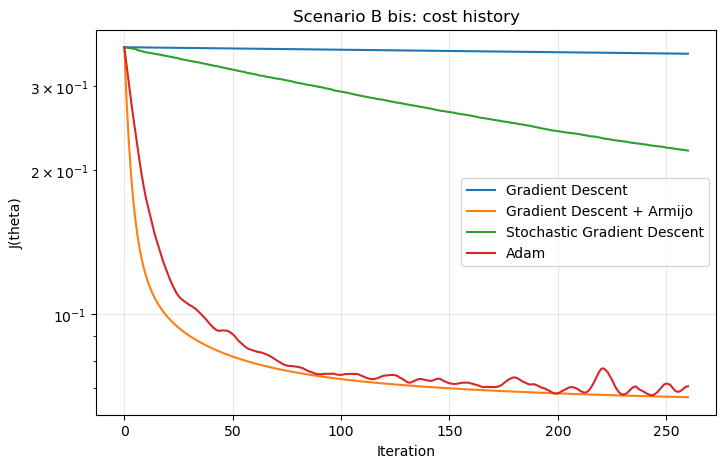

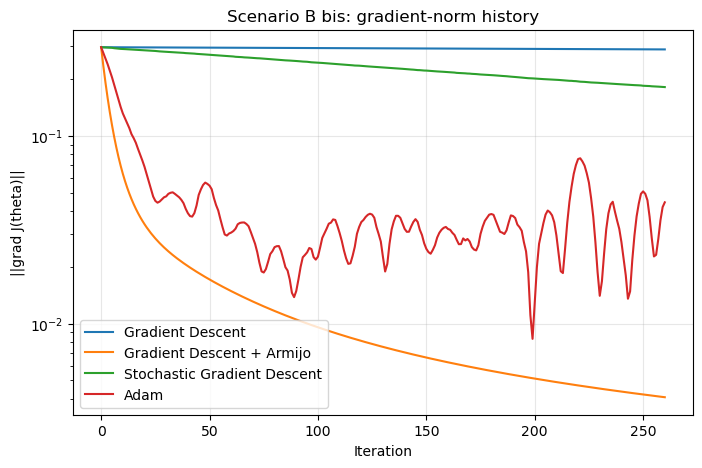

In [13]:
# Plot the cost histories for the noisy stochastic regime.
plot_cost_histories(results_hard2, "Scenario B bis: cost history")

# Plot the gradient norm histories for the noisy stochastic regime.
plot_grad_norm_histories(results_hard2, "Scenario B bis: gradient-norm history")


### Observation

This third scenario is the one where Adam should look strongest:

- SGD is noisy because the mini-batch is small
- Adam damps the noise through momentum and adaptive scaling
- full-gradient methods still work, but they are less realistic computationally on very large datasets


## Final comparison and conclusions


In [14]:
# Build a combined summary table.
combined_summary = pd.concat(
    [
        summary_easy.assign(Scenario="A: easy"),
        summary_hard.assign(Scenario="B: large-scale ill-conditioned"),
        summary_hard2.assign(Scenario="B bis: noisy mini-batch regime"),
    ],
    ignore_index=True,
)

# Reorder the columns.
combined_summary = combined_summary[
    ["Scenario", "Method", "Final cost", "Final grad norm", "Iterations"]
]

# Display the final comparison table.
combined_summary


,Scenario,Method,Final cost,Final grad norm,Iterations
0,A: easy,Gradient Descent,0.039157,0.051416,150
1,A: easy,Gradient Descent + Armijo,0.003128,0.005094,150
2,A: easy,Stochastic Gradient Descent,0.385265,0.234777,150
3,A: easy,Adam,0.001376,0.001438,150
4,B: large-scale ill-conditioned,Gradient Descent,0.304869,0.271725,220
5,B: large-scale ill-conditioned,Gradient Descent + Armijo,0.014522,0.004203,220
6,B: large-scale ill-conditioned,Stochastic Gradient Descent,0.130046,0.143805,220
7,B: large-scale ill-conditioned,Adam,0.012773,0.008933,220
8,B bis: noisy mini-batch regime,Gradient Descent,0.350849,0.288958,260
9,B bis: noisy mini-batch regime,Gradient Descent + Armijo,0.067036,0.004070,260


### Final conclusions

Using the same least-squares cost functional $J(\boldsymbol{\theta})$, we observed:

#### Scenario A
Gradient Descent is already very effective on a simple problem.

#### Scenario B
When the problem becomes large and ill-conditioned, mini-batch methods become much more relevant computationally.

#### Scenario B bis
When mini-batch noise becomes stronger, Adam often becomes more robust than plain SGD because it combines:
- stochastic gradients
- momentum
- adaptive scaling

This is why, in practice:
- Gradient Descent is a good baseline
- SGD is fundamental for large datasets
- Adam is often one of the most useful practical optimizers
